In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

# Path to the exported TensorRT model
tensorrt_model_path = '/content/runs/detect/train-8/weights/best.engine'

# Load the TensorRT model
model_trt = YOLO(tensorrt_model_path)

print(f"Loaded TensorRT model from: {tensorrt_model_path}")

# Path to the validation images directory, using the established new_dataset_base_path
val_images_dir = os.path.join('/content/crf-dataset-fresh', 'crf_val', 'images')

# Specify the target image name
sample_image_name_trt_2 = 'crf_image_15.png'
sample_image_path_trt_2 = os.path.join(val_images_dir, sample_image_name_trt_2)

print(f"Running inference with TensorRT model on sample image: {sample_image_path_trt_2}")

# Run inference using the TensorRT model
# Use a new name for the prediction run to avoid overwriting previous results
results_trt_2 = model_trt.predict(source=sample_image_path_trt_2, save=True, imgsz=1024, conf=0.5, name='predict_with_trt_image_15', half=True)

# Ultralytics often saves results as .jpg even if input was .png
output_image_path_trt_2 = os.path.join(results_trt_2[0].save_dir, os.path.splitext(sample_image_name_trt_2)[0] + '.jpg')

if os.path.exists(output_image_path_trt_2):
    print(f"\n--- Inference Results with TensorRT on {sample_image_name_trt_2} ---")
    display(Image(filename=output_image_path_trt_2))
else:
    print(f"Predicted image not found at: {output_image_path_trt_2}")

# Optional: Print detected bounding boxes and classes
print("\n--- Detections (TensorRT) ---")
for r in results_trt_2:
    for box in r.boxes:
        c = int(box.cls)
        conf = box.conf.item()
        xyxy = box.xyxy[0].tolist()
        print(f"Class: {model_trt.names[c]}, Confidence: {conf:.2f}, Bounding Box: {xyxy}")

Test Output:
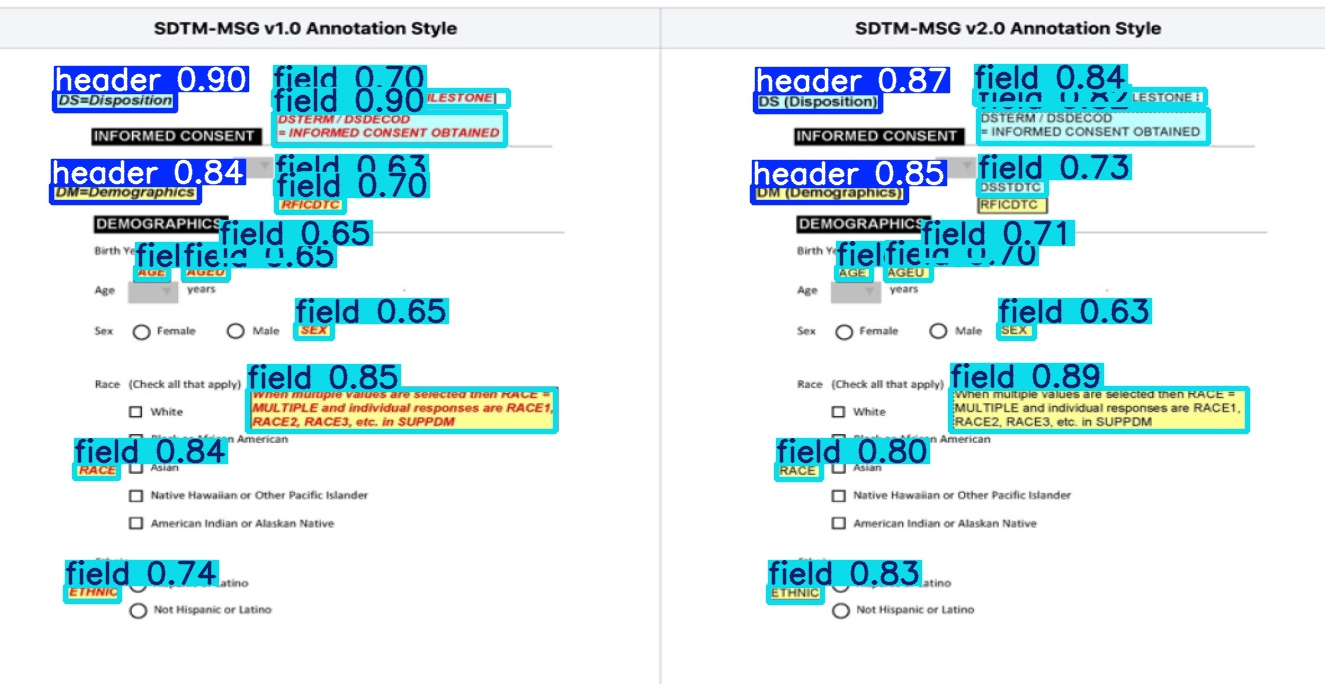

Calculate Average Inference Time

To get a more representative measure of the TensorRT model's performance, let's calculate the average inference time over a larger set of validation images. This will involve running inference on multiple images and then averaging the reported inference speeds.
[ ]


In [ ]:
from ultralytics import YOLO
import os
import time

# Path to the exported TensorRT model
tensorrt_model_path = '/content/runs/detect/train-8/weights/best.engine'

# Load the TensorRT model once
model_trt = YOLO(tensorrt_model_path)
print(f"Loaded TensorRT model from: {tensorrt_model_path}")

# Path to the validation images directory, using the established new_dataset_base_path
val_images_dir = os.path.join('/content/crf-dataset-fresh', 'crf_val', 'images')

# Get a list of all validation images
all_val_images = [f for f in os.listdir(val_images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Use all available validation images for average calculation
sample_images_for_avg = sorted(all_val_images)

if not sample_images_for_avg:
    print("No validation images found to calculate average inference time.")
else:
    inference_times_ms = []
    print(f"\nCalculating average inference time over {len(sample_images_for_avg)} images...")

    for i, image_name in enumerate(sample_images_for_avg):
        image_path = os.path.join(val_images_dir, image_name)
        print(f"  ({i+1}/{len(sample_images_for_avg)}) Inferring on: {image_name}")

        # Run inference and capture results
        # We don't need to save or display results for this calculation
        results = model_trt.predict(
            source=image_path,
            save=False, # Do not save predicted images
            imgsz=1024,
            conf=0.5,
            half=True,
            verbose=False # Suppress verbose output for each image
        )

        # Extract inference time from the results object
        # Ultralytics results objects contain speed information
        if results and hasattr(results[0], 'speed'):
            # Inference speed is usually reported in ms
            inference_time_ms = results[0].speed['inference']
            inference_times_ms.append(inference_time_ms)
            print(f"    Inference time for {image_name}: {inference_time_ms:.2f} ms")
        else:
            print(f"    Could not extract inference time for {image_name}")

    if inference_times_ms:
        average_inference_time_ms = sum(inference_times_ms) / len(inference_times_ms)
        print(f"\nAverage inference time across {len(inference_times_ms)} images: {average_inference_time_ms:.2f} ms")
    else:
        print("No inference times collected.")

In [ ]:
import pandas as pd
import os

# Ensure inference_times_ms and sample_images_for_avg are available
# (These variables are generated by the previous cell '931e3779')
if 'inference_times_ms' in locals() and 'sample_images_for_avg' in locals():
    if inference_times_ms and sample_images_for_avg:
        # Create a DataFrame from the inference results
        inference_summary_df = pd.DataFrame({
            'Image Name': sample_images_for_avg,
            'Inference Time (ms)': inference_times_ms
        })

        # Add the overall average inference time for reference
        overall_avg_inference_time = sum(inference_times_ms) / len(inference_times_ms)
        inference_summary_df['Overall Average (ms)'] = overall_avg_inference_time

        # Define the path for the output CSV file
        output_csv_path = '/content/tensorrt_inference_summary.csv'

        # Save the DataFrame to a CSV file
        inference_summary_df.to_csv(output_csv_path, index=False)

        print(f"Inference summary saved to: {output_csv_path}")
        display(inference_summary_df.head())
    else:
        print("No inference data available to save to CSV.")
else:
    print("Error: 'inference_times_ms' or 'sample_images_for_avg' not found. Please run the previous cell first.")

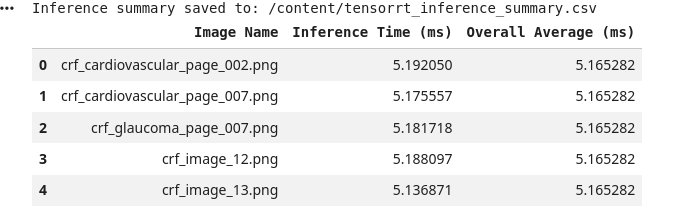

In [ ]:
import numpy as np

# Ensure inference_times_ms is available
if 'inference_times_ms' in locals() and inference_times_ms:
    std_dev_inference_time_ms = np.std(inference_times_ms)
    print(f"Standard deviation of inference times: {std_dev_inference_time_ms:.2f} ms")
else:
    print("No inference times data available to calculate standard deviation.")

In [ ]:
from google.colab import files

output_csv_path = '/content/tensorrt_inference_summary.csv'

if os.path.exists(output_csv_path):
    files.download(output_csv_path)
    print(f"Downloading {output_csv_path}...")
else:
    print(f"Error: CSV file not found at {output_csv_path}")

In [ ]:
## Download Tested Inference Engine.
from google.colab import files
import os

# Define the path to the best.engine file
engine_file_path = '/content/runs/detect/train-8/weights/best.engine'

if os.path.exists(engine_file_path):
    print(f"Downloading {engine_file_path}...")
    files.download(engine_file_path)
else:
    print(f"Error: The engine file was not found at {engine_file_path}")
